## Individual Preprocessing Technique: Handling Missing Data
**Member:** Wickramasinghe G.D.M.H | IT25102064

**Dataset:** Adult Income Dataset (UCI Machine Learning Repository)

**Purpose:** Identify, quantify, and resolve missing values in the dataset

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

output_dir = os.path.join("..", "results", "eda_visualizations")
os.makedirs(output_dir, exist_ok=True)

#1 Load raw dataset

df = pd.read_csv('../data/raw/adult.csv')
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (32561, 15)


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


## Step 1: Convert placeholder values to NaN
The Adult dataset marks missing entries as `'?'` instead of a proper null value, so pandas'
built-in missing-value functions (`isnull()`, `dropna()`, `fillna()`) won't detect them until
they're converted to `NaN` first.

In [22]:
df.replace('?', np.nan, inplace=True)

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,NaN,77053,HS-grad,9,Widowed,NaN,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,NaN,186061,Some-college,10,Widowed,NaN,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,22,Private,310152,Some-college,10,Never-married,Protective-serv,Not-in-family,White,Male,0,0,40,United-States,<=50K
32557,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32558,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32559,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K


## Step 2: Identify missing values per column
Checking which columns are affected and by how much, both as raw counts and as a
percentage of the full dataset.

In [23]:
missing_counts = df.isnull().sum()
missing_cols = missing_counts[missing_counts > 0]
print("Missing values per column:")
print(missing_cols)
 
missing_percent = (missing_cols / len(df)) * 100
print("\nMissing values as % of dataset:")
print(missing_percent.round(2))

Missing values per column:
workclass         1836
occupation        1843
native.country     583
dtype: int64

Missing values as % of dataset:
workclass         5.64
occupation        5.66
native.country    1.79
dtype: float64


## Step 3: Identify missing values per row
Column-level counts can be misleading if the same rows are missing multiple fields.
This checks how many *unique rows* are affected overall.

In [24]:
rows_with_missing = df[df.isnull().any(axis=1)]
print(f"\nRows with at least one missing value: {len(rows_with_missing)}")
print(f"Percentage of dataset affected: {len(rows_with_missing) / len(df) * 100:.2f}%")


Rows with at least one missing value: 2399
Percentage of dataset affected: 7.37%


## Step 4: Check overlap between workclass and occupation
Hypothesis: these two fields are missing together<br>
eg:- individuals who are unemployed or have never worked would naturally have no workclass and no occupation listed.

In [25]:
both_missing = df[df['workclass'].isnull() & df['occupation'].isnull()]
print(f"\nRows missing BOTH workclass and occupation: {len(both_missing)}")
print(f"(out of {df['workclass'].isnull().sum()} workclass-missing and "
      f"{df['occupation'].isnull().sum()} occupation-missing rows)")


Rows missing BOTH workclass and occupation: 1836
(out of 1836 workclass-missing and 1843 occupation-missing rows)


## Step 5: EDA Visualization - missing values by column

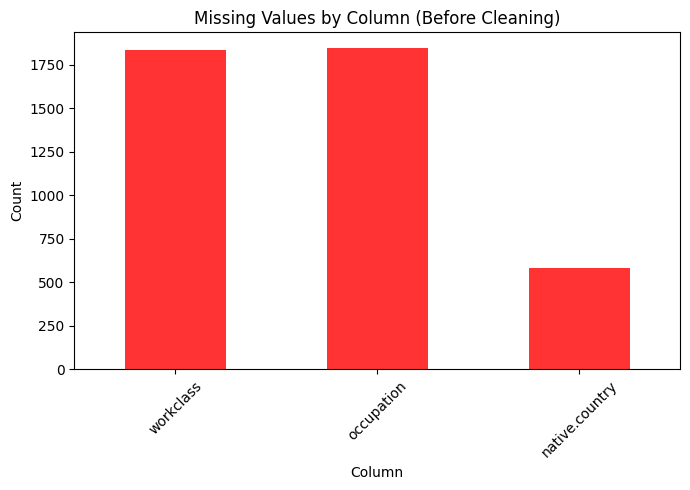

In [26]:
plt.figure(figsize=(7, 5))

missing_cols.plot(kind='bar', color='#FF3333')
plt.title('Missing Values by Column (Before Cleaning)')
plt.ylabel('Count')
plt.xlabel('Column')
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(
    os.path.join(
        output_dir,
        "IT25102064_Missing_Values_Before_Cleaning.png"
    ),
    dpi=110,
    bbox_inches="tight"
)

plt.show()

**Interpretation:**

- `workclass` (1,836) and `occupation` (1,843) are missing in almost identical numbers
- The overlap check above confirms all 1,836 workclass-missing rows are also missing occupation, consistent with unemployed or never-worked individuals leaving both fields blank together
- `native.country` (583) is a much smaller and largely independent gap, more likely due to unreported nationality than any employment-related pattern

## Step 6: Handle missing values - Mode imputation
**Why mode imputation:** all three affected columns are categorical, so mean/median
imputation doesn't apply. With only 5.64–5.66% missingness in `workclass`/`occupation`
and 1.79% in `native.country`, imputing preserves the full 32,561-row dataset rather than
losing ~7% of rows by dropping them.

**Tradeoff:** mode imputation slightly inflates the majority category and may dampen the signal from what could be a distinct subgroup (e.g. unemployed individuals) - worth flagging as a caveat if it affects model performance later.

In [27]:
before_counts = df[['workclass', 'occupation', 'native.country']].isnull().sum()
 
for col in ['workclass', 'occupation', 'native.country']:
    mode_value = df[col].mode()[0]
    df[col] = df[col].fillna(mode_value)
    print(f"'{col}' imputed with mode value: '{mode_value}'")
 
after_counts = df[['workclass', 'occupation', 'native.country']].isnull().sum()

'workclass' imputed with mode value: 'Private'
'occupation' imputed with mode value: 'Prof-specialty'
'native.country' imputed with mode value: 'United-States'


## Step 7: Verify imputation worked

In [28]:
#8 Verify imputation worked

print("\nMissing values BEFORE imputation:")
print(before_counts)
print("\nMissing values AFTER imputation:")
print(after_counts)
 
assert after_counts.sum() == 0, "There are still missing values remaining!"
print("\nAll missing values in workclass, occupation, and native.country resolved.")


Missing values BEFORE imputation:
workclass         1836
occupation        1843
native.country     583
dtype: int64

Missing values AFTER imputation:
workclass         0
occupation        0
native.country    0
dtype: int64

All missing values in workclass, occupation, and native.country resolved.


## Step 8: Final check across the entire dataset
Confirms no missing values remain anywhere in the dataframe before handing off to the
next preprocessing step (duplicates/outliers) in the group pipeline.

In [29]:
#9 Final check

print("\nRemaining missing values across entire dataset:", df.isnull().sum().sum())


Remaining missing values across entire dataset: 0
